<a href="https://colab.research.google.com/github/Josep1990/data-preparation-for-finance/blob/data-preparation-basics/MLBTC_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pickle
import pandas as pd
import datetime, time
import math
import matplotlib.pyplot as plt



In [11]:
df = pd.read_csv(f"BTCUSDT-15m-data.csv")

df.head()

close_price = df["close"]

In [18]:
window = 96 * 30
moving_svg = []

for i in range(len(close_price)):
    if i < window - 1:
        moving_svg.append(np.nan)
    else:
        window_data = close_price[i - window +1 :i + 1]
        mean = np.mean(window_data)
        moving_svg.append(mean)

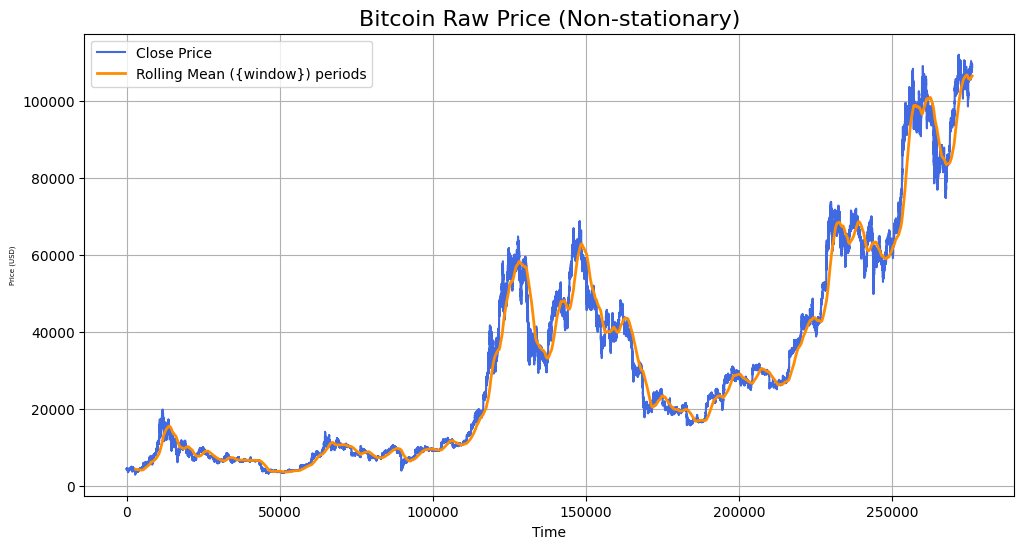

In [19]:


plt.figure(figsize=(12, 6))
plt.plot(close_price, color='royalblue', label='Close Price')
plt.plot(moving_svg, color='darkorange', linewidth = 2, label='Rolling Mean ({window}) periods')
plt.title('Bitcoin Raw Price (Non-stationary)', fontsize=16)
plt.xlabel('Time')
plt.ylabel('Price (USD)', fontsize=5)
plt.legend()
plt.grid()
plt.show()

non-stationary is a important concept in ML

1: what stationary means in pratical terms.

2: how to visually identify stationary vs non-stationary data

3: how to transform Bitcoin data to make it stationary

4: why this matters for your trading strategies

Stationary:

The Mean (average) changes over time
The Variance changes over time



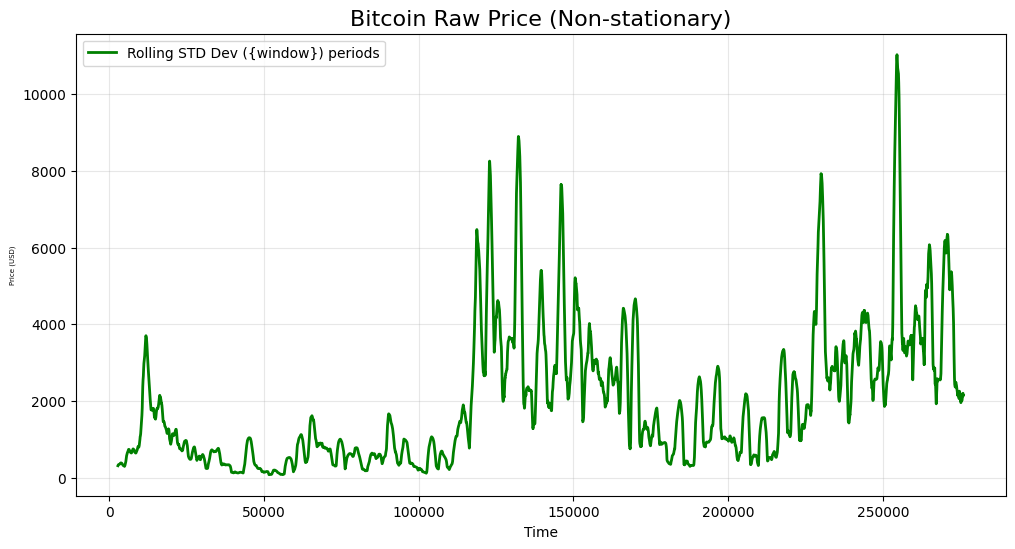

In [17]:
window = 96 * 30
moving_std = []

for i in range(len(close_price)):
    if i < window - 1:
        moving_std.append(np.nan)
    else:
        window_data = close_price[i - window +1 :i + 1]
        std = np.std(window_data, ddof=1)
        moving_std.append(std)


#plot with std statitics

plt.figure(figsize=(12, 6))
plt.plot(moving_std, color='green', linewidth = 2, label='Rolling STD Dev ({window}) periods')
plt.title('Bitcoin Raw Price (Non-stationary)', fontsize=16)
plt.xlabel('Time')
plt.ylabel('Price (USD)', fontsize=5)
plt.legend()
plt.grid(alpha = 0.3)
plt.show()

Stationary Transformation

Log Differencing

Percentage Change

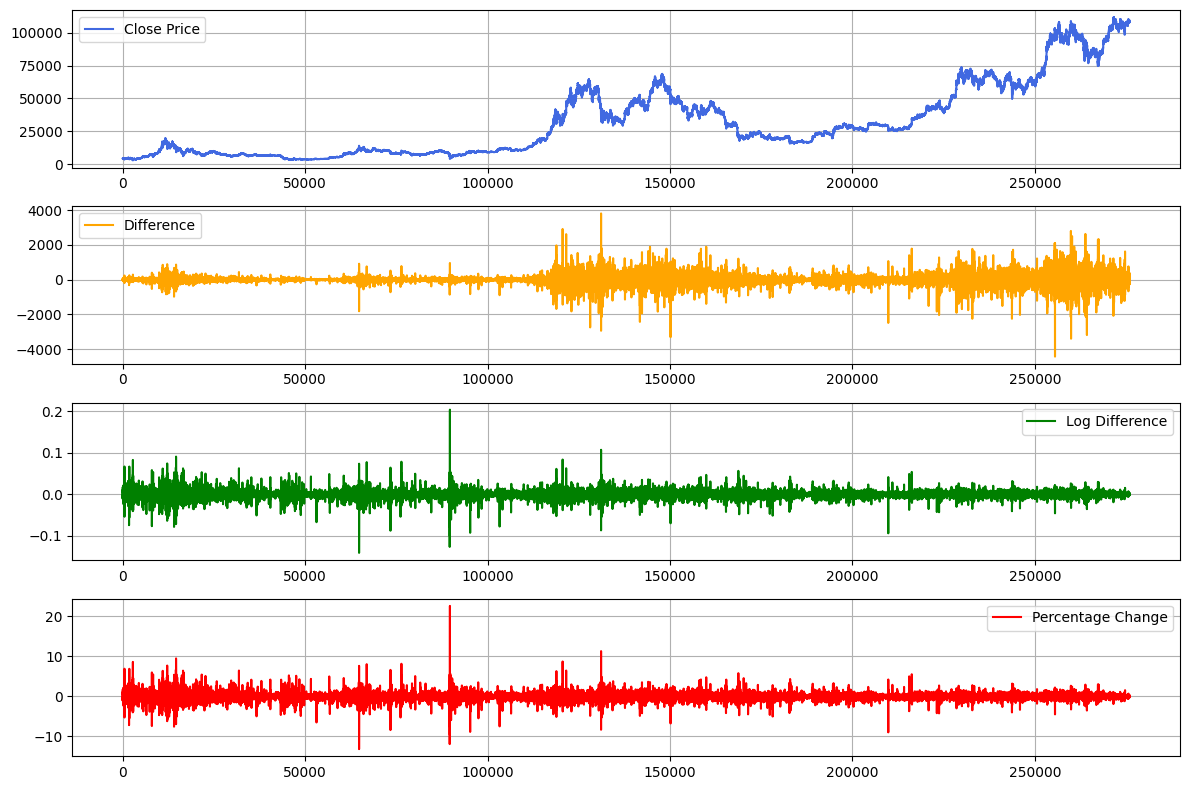

In [21]:
from ast import PyCF_TYPE_COMMENTS
from logging import log
#Differencing

diff_price = []

for i in range(1, len(close_price)):
    diff_price.append(close_price[i] - close_price[i - 1])

#---------------------------------
# Approach 1: Log Differencing
#---------------------------------

log_price = np.log(close_price)
log_diff_price = [np.nan]

for i in range(1, len(log_price)):
    log_diff_price.append(log_price[i] - log_price[i - 1])

#--------------------------------
# Approach 2: Percentage Change
#--------------------------------

pct_change_price = [np.nan]

for i in range(1, len(close_price)):
    pct_change_price.append(((close_price[i] - close_price[i - 1]) / close_price[i - 1]) * 100)


#-------------------------------
#     Plot Data
#-------------------------------

plt.figure(figsize=(12, 8))

plt.subplot(4, 1, 1)
plt.plot(close_price, color='royalblue', label='Close Price')
plt.legend()
plt.grid()

plt.subplot(4, 1, 2)
plt.plot(diff_price, color='orange', label='Difference')
plt.legend()
plt.grid()

plt.subplot(4, 1, 3)
plt.plot(log_diff_price, color='green', label='Log Difference')
plt.legend()
plt.grid()

plt.subplot(4, 1, 4)
plt.plot(pct_change_price, color='red', label='Percentage Change')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()



Processing

1 - Splitting the data into training and testing sets

2 - Preprocessing both the training data adn the testing data into the right structure.

